# Director Skill Sets Table 7 - Appointments only

In [1]:
import pandas_datareader.data as web #to collect data
import datetime as dt #to specify start and end dates

# import yfinance as yf

import eventstudy as es
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mpl_toolkits as mplot3d
%matplotlib inline
import seaborn as sns

import scipy.stats as stats
from scipy.stats.mstats import winsorize
from scipy.spatial.distance import cdist


from sklearn.neighbors import NearestNeighbors

import pandas as pd

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.rolling import RollingOLS

from sklearn.preprocessing import StandardScaler

from patsy import dmatrices
from tqdm.notebook import tqdm
tqdm.pandas()

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [2]:
import_folder_path = rf"..\..\..\..\[IN USE] Rookie Directors\[4] FF3 CAR\car_output4"
output_folder_path = "analysis_outputs"
# pca_input_folder_path = rf"..\..\..\[IN USE] Rookie Directors\[1.5] Director Skills PCA\director_skills_pca"
firm_input_folder_path = rf"..\..\..\..\[IN USE] Rookie Directors\[2] Firm Level Wrangling\Firm level Iterative\Firm Lev + Fin\City level\city_lev_output"
filtering_folder_path = rf"..\..\..\..\[IN USE] Rookie Directors\[4] FF3 CAR\car_filtering"
supporting_folder_path = "supporting_datafiles"

In [3]:
dirFirm00 = pd.read_pickle(rf"{import_folder_path}\Director Level_FF3_CAR.pkl")
dirFirm00 = dirFirm00.loc[ dirFirm00["date_source"] == "Appointment Date"].reset_index(drop = True)

# pca = pd.read_pickle(rf"{pca_input_folder_path}\Main_Director_COMPLETE_PCA.pkl")
firm = pd.read_pickle(rf"{firm_input_folder_path}\Main_Firm_COMPLETE.pkl")

In [4]:
# pca_col = [
#     "Person Code", "AsOnDate", "Symbol",
#     "SkillsetIndex", "SkillsetGeneralistDummy",
#     "PC1_FactorScore", "PC1_FactorScore_Standardised"
# ]

# pca2 = pca[pca_col].copy()
# dirFirm00 = dirFirm0.merge(pca2, on = ["Person Code", "AsOnDate", "Symbol"], how = "left")

In [5]:
firm_col = [
    "AsOnDate", "Symbol",

    "PercentWomenDir", "PercentBusyDir",
    "LnBoardSize", "PercentIndep",
    "Promoters_percent", "NonpromoterInstitutions_percent", "RD to Assets",
    "ln_marcap", "ln_rdtoassets", "Debt to equity ratio", # control variables
    
    "FamilyOwnedFamilyCeoChair25", "promoterholding25", "HasFamilyChairmanAndCEO",
]

firm2 = firm[firm_col].copy()
dirFirm = dirFirm00.merge(firm2, on = ["AsOnDate", "Symbol"], how = "left")

In [6]:
# dirFirm data wrangling if any:
dirFirm["Year of Study"] = [x.year for x in dirFirm["Date of Study"]]

dirFirm = dirFirm.drop_duplicates(subset = ["Person Code", "Company", "Date of Study"]).reset_index(drop = True)

dirFirm["ln_dirage"] = np.log(dirFirm["Age"] + 1).astype("float")
dirFirm["ln_directorships"] = np.log((dirFirm["CompCountCurrTotalAB"] - 1) + 1).astype("float")

In [7]:
dirFirm.replace([np.inf, -np.inf], pd.NA, inplace = True)

# PSM

## Verifying and removing those rows with no control data points

In [8]:
# Sample constraints ---> govtdummy==0 & findummy==0 & asonyear>2012
# dirFirm.columns.to_list()

In [9]:
dirFirm["IsDualityChairmanMD"] = dirFirm["IsDualityChairmanMD"].astype(int)


dirFirm["NIC_1digit"] = dirFirm["NIC code"].dropna().apply(lambda x: x[0:1])
dirFirm["NIC_1digit"] = dirFirm["NIC_1digit"]

dirFirm.loc[dirFirm["RD to Assets"] == 0, "ln_rdtoassets"] = 0

psmSample = dirFirm.loc[ (dirFirm["Year of Study"] >= 2013) 
    & (dirFirm["govtdummy"] == 0) & (dirFirm["findummy"] == 0) ].copy()
#.dropna(subset = controlVars).dropna(subset = dependentVar).copy()

# psmSample["DummySum"] = psmSample["IsRookie"] + psmSample["IsNonRookie"]
psmSample["DummySumIndep"] = psmSample["IsRookieIndep"] + psmSample["IsNonRookieIndep"]

# psmSampleAll = psmSample.loc[ psmSample["DummySum"] == 1 ].reset_index(drop = True)
# psmSampleAll = psmSampleAll.loc[ ~psmSampleAll.duplicated(subset = ["AsOnDate", "Symbol", "Appointment Date"], keep = False)]

psmSampleIndep = psmSample.loc[ psmSample["DummySumIndep"] == 1 ].reset_index(drop = True)
# psmSampleIndep = psmSampleIndep.loc[ ~psmSampleIndep.duplicated(subset = ["AsOnDate", "Symbol", "Appointment Date"], keep = False)]

## CAR windsorization

       winsorised_120CAR3  nonwinsorised_120CAR3
count         6556.000000            6556.000000
mean            -0.003889              -0.003889
std              0.124688               0.124688
min             -5.881178              -5.881178
25%             -0.037683              -0.037683
50%             -0.004026              -0.004026
75%              0.032332               0.032332
max              0.635987               0.635987


Top values and their count:  nonwinsorised_120CAR3
0.325069    1
0.334612    2
0.335937    1
0.342841    1
0.365209    1
0.371801    1
0.375992    1
0.516621    1
0.586782    1
0.635987    1
Name: count, dtype: int64





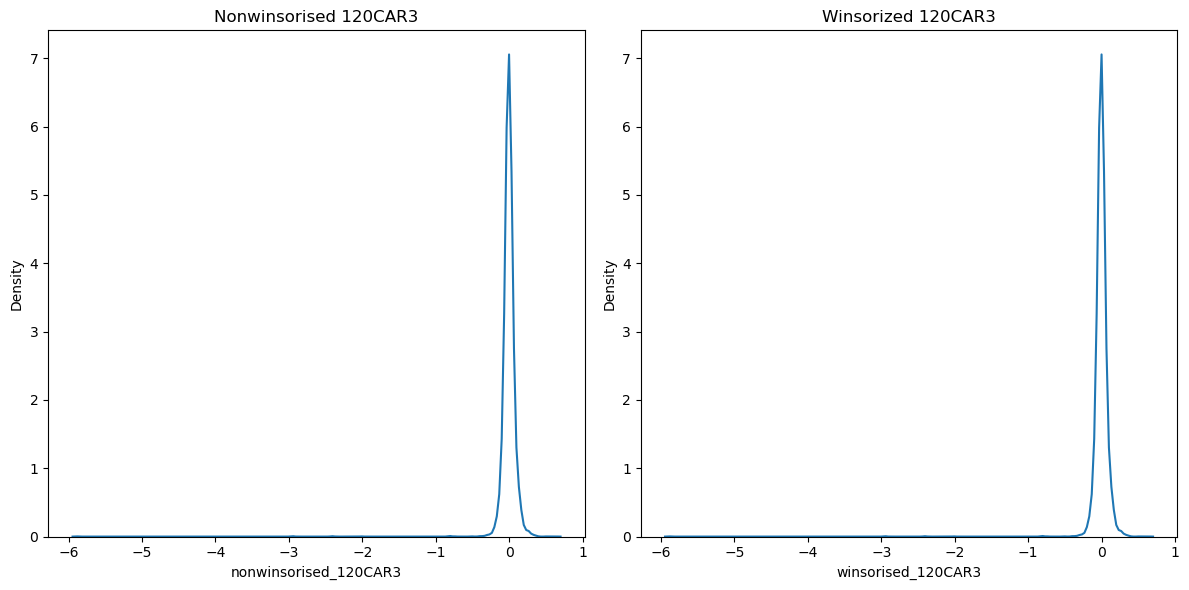

       winsorised_120CAR5  nonwinsorised_120CAR5
count         6554.000000            6554.000000
mean            -0.054247              -0.054247
std              0.158696               0.158696
min             -7.810134              -7.810134
25%             -0.094760              -0.094760
50%             -0.053850              -0.053850
75%             -0.011938              -0.011938
max              0.845454               0.845454


Top values and their count:  nonwinsorised_120CAR5
0.366186    1
0.368257    1
0.379506    1
0.387378    1
0.477138    2
0.545864    1
0.602070    1
0.624013    1
0.671093    1
0.845454    1
Name: count, dtype: int64





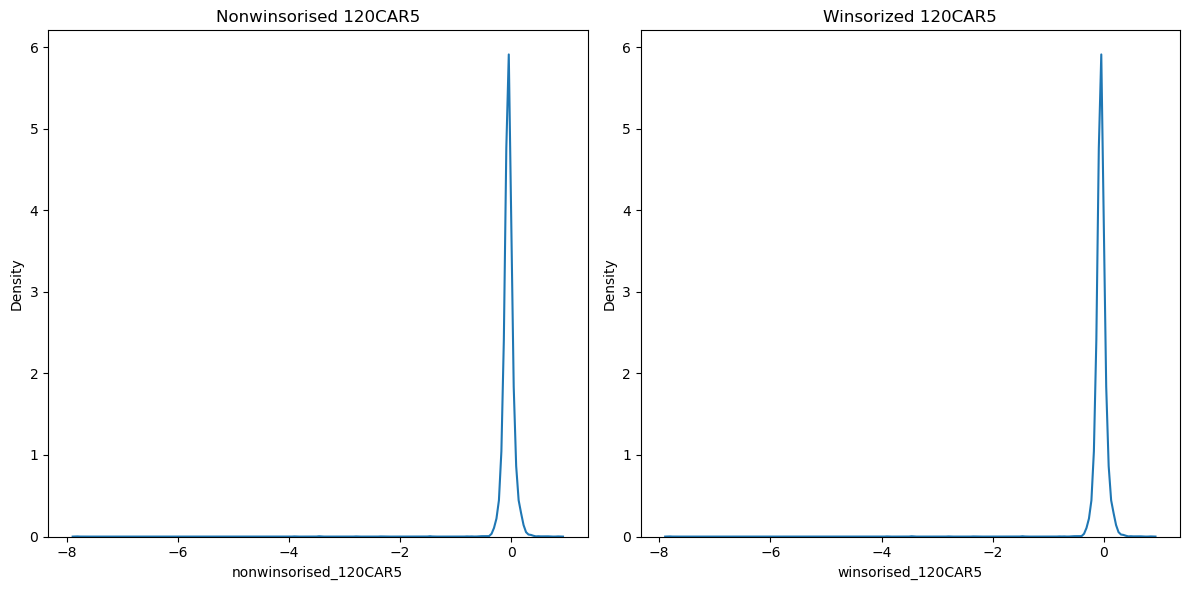

       winsorised_120CAR7  nonwinsorised_120CAR7
count         6552.000000            6552.000000
mean            -0.103631              -0.103631
std              0.177620               0.177620
min             -6.881928              -6.881928
25%             -0.156001              -0.156001
50%             -0.101354              -0.101354
75%             -0.050032              -0.050032
max              1.338337               1.338337


Top values and their count:  nonwinsorised_120CAR7
0.363112    1
0.372496    1
0.392494    2
0.400824    1
0.412386    1
0.511402    1
0.515160    1
0.537508    1
0.614655    2
1.338337    1
Name: count, dtype: int64





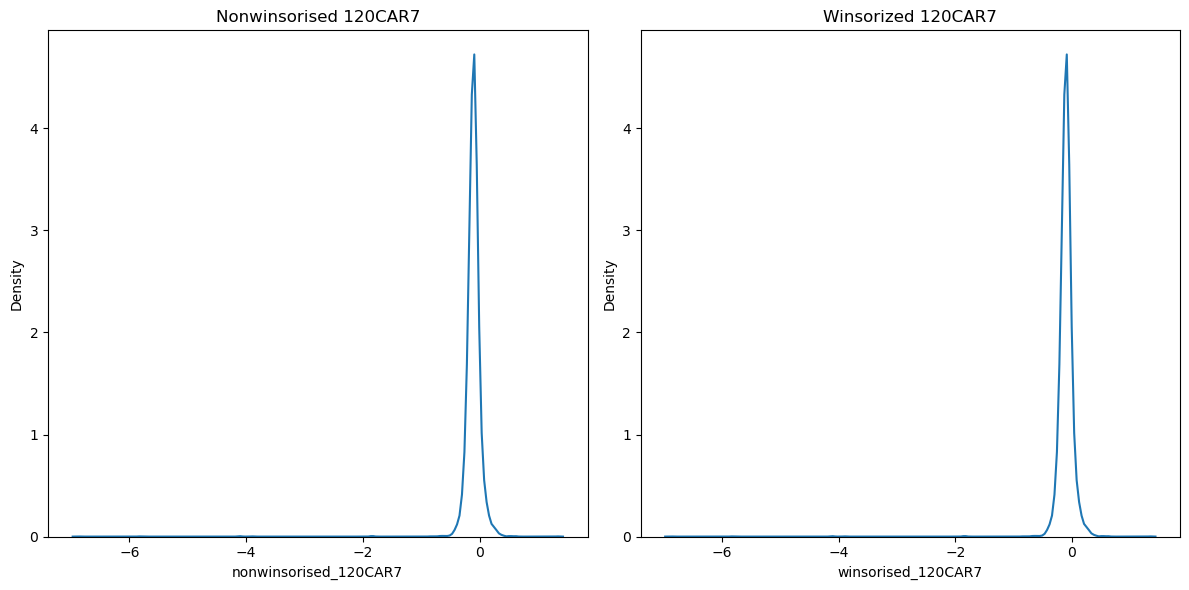

       winsorised_120CAR11  nonwinsorised_120CAR11
count          6543.000000             6543.000000
mean             -0.198132               -0.198132
std               0.209915                0.209915
min              -8.398723               -8.398723
25%              -0.269014               -0.269014
50%              -0.200280               -0.200280
75%              -0.124648               -0.124648
max               2.020538                2.020538


Top values and their count:  nonwinsorised_120CAR11
0.419622    1
0.427879    1
0.433417    2
0.443446    2
0.513692    1
0.514836    1
0.541985    1
0.554495    1
0.794391    1
2.020538    1
Name: count, dtype: int64





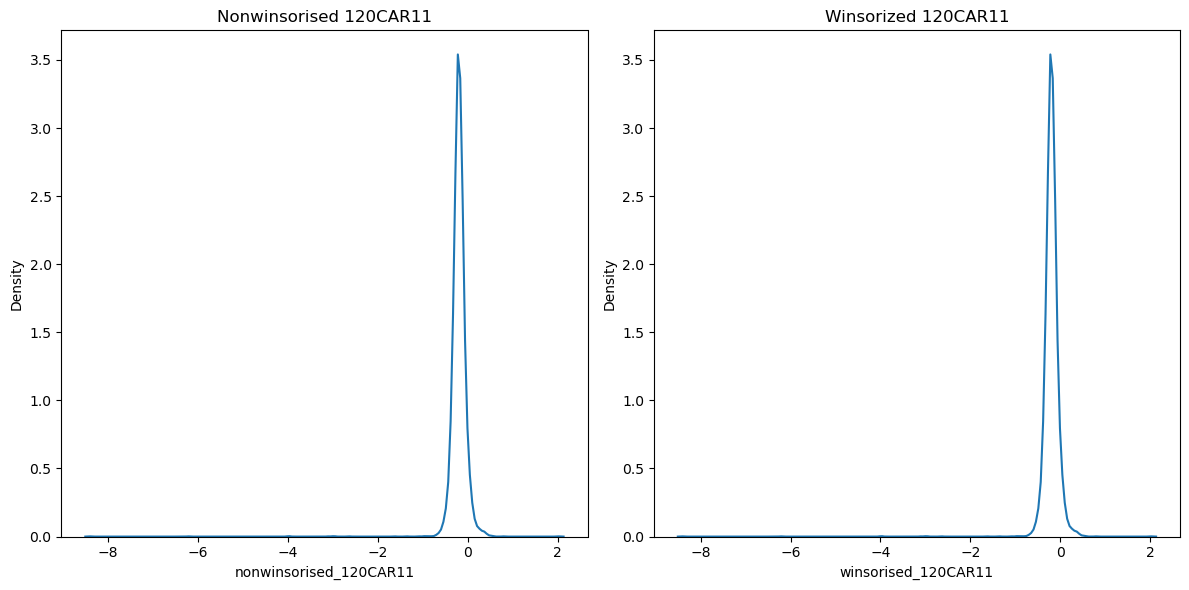

       winsorised_150CAR3  nonwinsorised_150CAR3
count         6528.000000            6528.000000
mean            -0.003809              -0.003809
std              0.118104               0.118104
min             -5.069603              -5.069603
25%             -0.037407              -0.037407
50%             -0.003686              -0.003686
75%              0.032089               0.032089
max              0.644012               0.644012


Top values and their count:  nonwinsorised_150CAR3
0.315817    1
0.327423    1
0.330246    2
0.343932    1
0.365220    1
0.375913    1
0.377561    1
0.519500    1
0.589509    1
0.644012    1
Name: count, dtype: int64





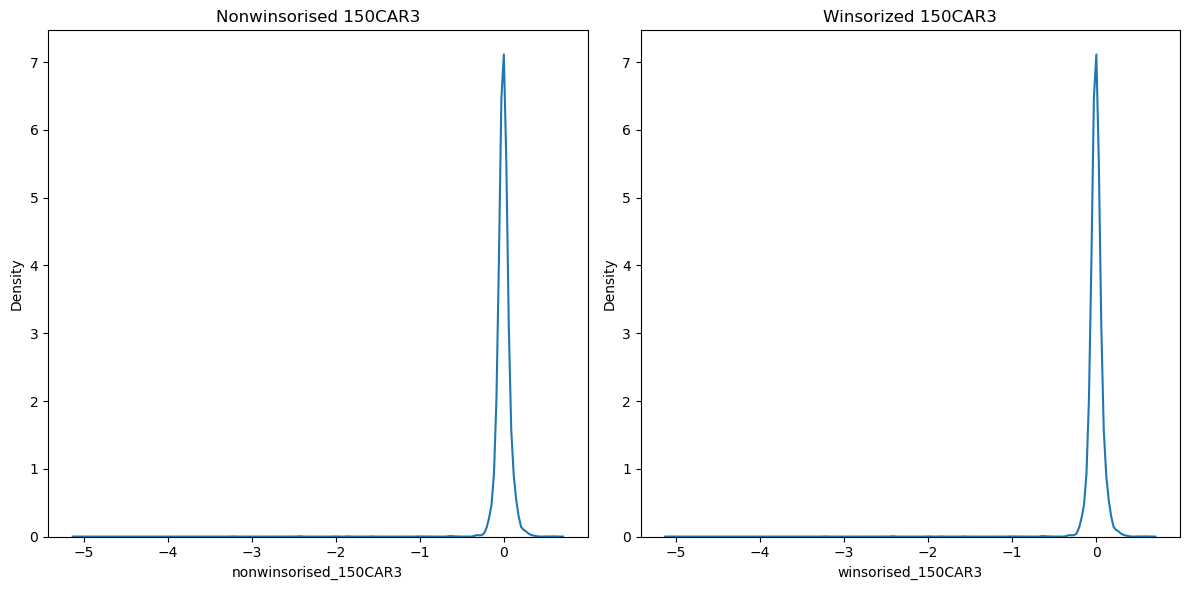

       winsorised_150CAR5  nonwinsorised_150CAR5
count         6526.000000            6526.000000
mean            -0.054430              -0.054430
std              0.157389               0.157389
min             -6.807206              -6.807206
25%             -0.094743              -0.094743
50%             -0.054254              -0.054254
75%             -0.012220              -0.012220
max              0.852672               0.852672


Top values and their count:  nonwinsorised_150CAR5
0.370070    1
0.378620    1
0.381529    1
0.389460    1
0.465221    2
0.549512    1
0.606011    1
0.652591    1
0.692687    1
0.852672    1
Name: count, dtype: int64





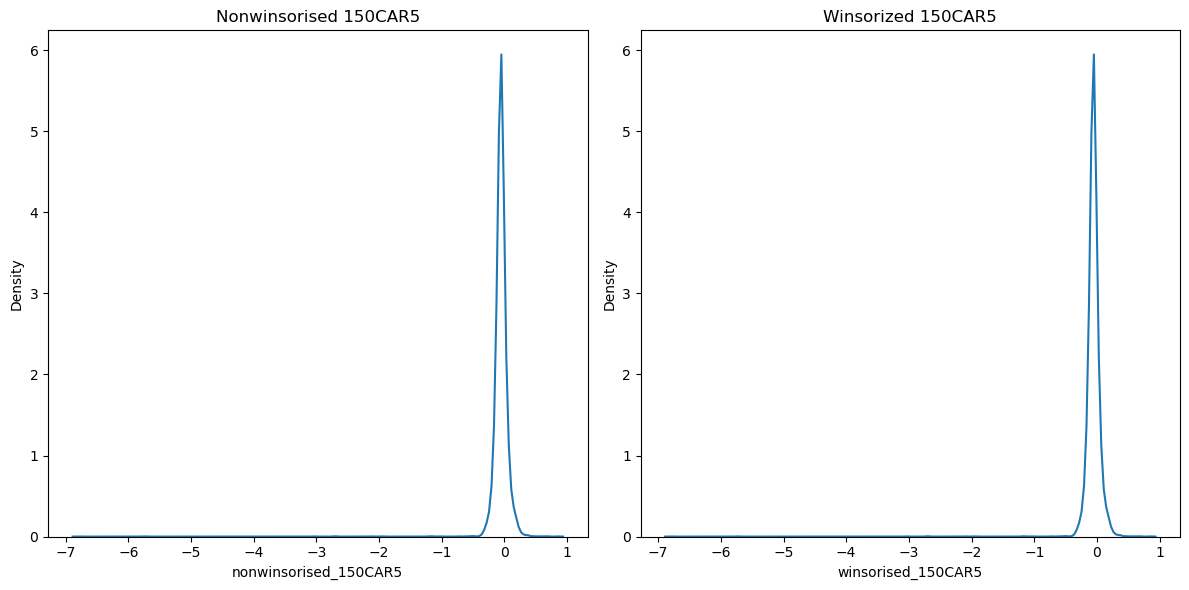

       winsorised_150CAR7  nonwinsorised_150CAR7
count         6524.000000            6524.000000
mean            -0.103641              -0.103641
std              0.171787               0.171787
min             -5.981582              -5.981582
25%             -0.156357              -0.156357
50%             -0.102031              -0.102031
75%             -0.050477              -0.050477
max              1.340499               1.340499


Top values and their count:  nonwinsorised_150CAR7
0.369048    1
0.369563    1
0.392125    2
0.393378    1
0.416879    1
0.512089    1
0.512836    1
0.606768    2
0.627795    1
1.340499    1
Name: count, dtype: int64





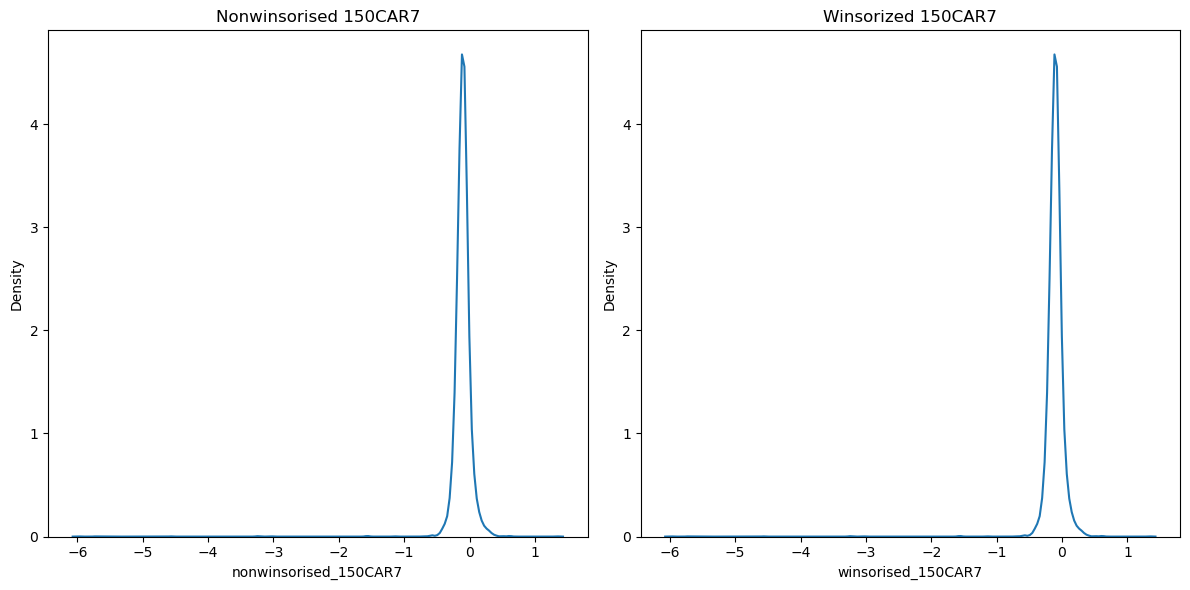

       winsorised_150CAR11  nonwinsorised_150CAR11
count          6515.000000             6515.000000
mean             -0.198046               -0.198046
std               0.206681                0.206681
min              -7.652167               -7.652167
25%              -0.268778               -0.268778
50%              -0.199729               -0.199729
75%              -0.124328               -0.124328
max               2.023445                2.023445


Top values and their count:  nonwinsorised_150CAR11
0.411787    1
0.429190    1
0.434419    2
0.442599    2
0.469637    1
0.483166    1
0.512201    1
0.543344    1
0.789837    1
2.023445    1
Name: count, dtype: int64





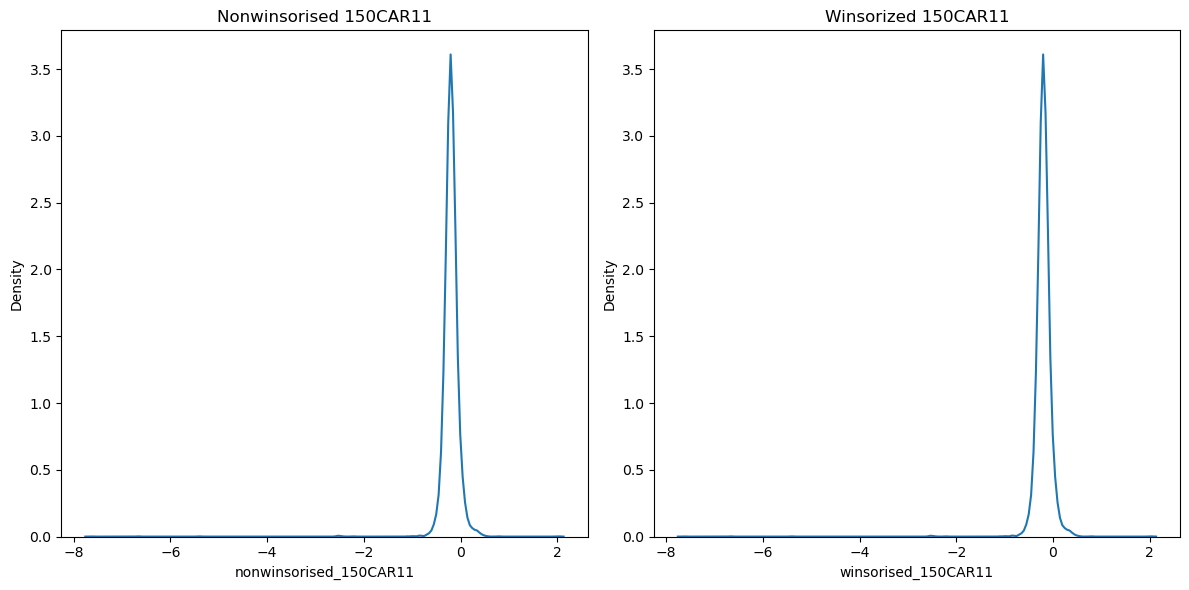

       winsorised_180CAR3  nonwinsorised_180CAR3
count         6492.000000            6492.000000
mean            -0.003322              -0.003322
std              0.107050               0.107050
min             -4.380580              -4.380580
25%             -0.037561              -0.037561
50%             -0.003530              -0.003530
75%              0.031752               0.031752
max              0.644617               0.644617


Top values and their count:  nonwinsorised_180CAR3
0.317328    1
0.325482    2
0.331315    1
0.340944    1
0.368445    1
0.380822    1
0.384746    1
0.512948    1
0.593403    1
0.644617    1
Name: count, dtype: int64





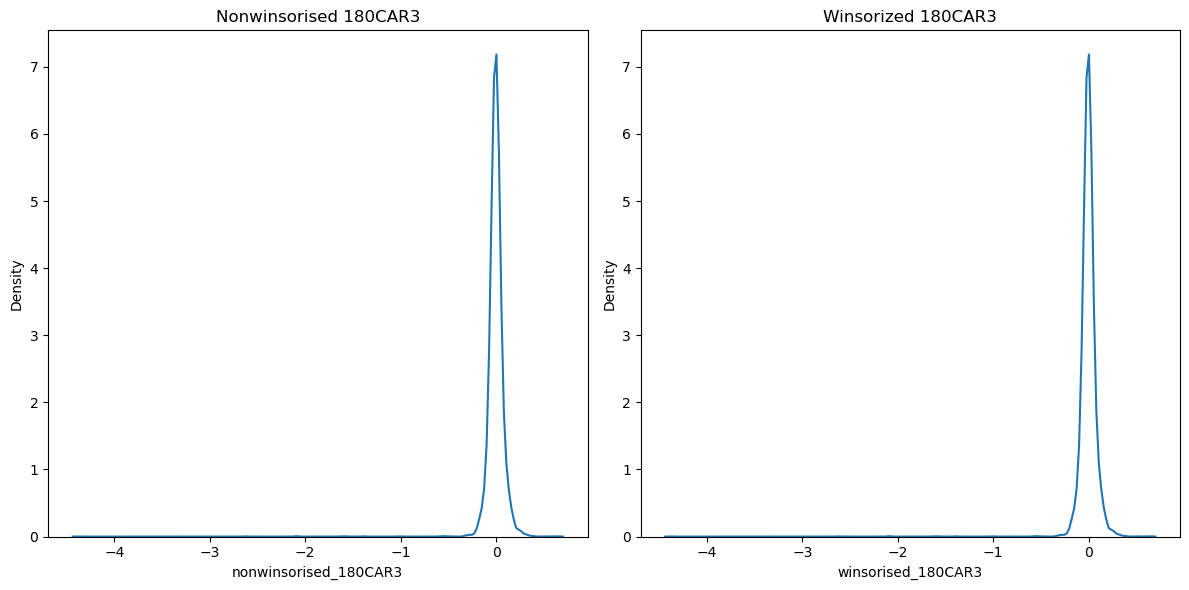

       winsorised_180CAR5  nonwinsorised_180CAR5
count         6490.000000            6490.000000
mean            -0.053852              -0.053852
std              0.141862               0.141862
min             -5.953411              -5.953411
25%             -0.095387              -0.095387
50%             -0.054544              -0.054544
75%             -0.012339              -0.012339
max              0.860962               0.860962


Top values and their count:  nonwinsorised_180CAR5
0.375467    1
0.378772    1
0.392295    1
0.392543    1
0.455349    2
0.544237    1
0.597730    1
0.678142    1
0.715774    1
0.860962    1
Name: count, dtype: int64





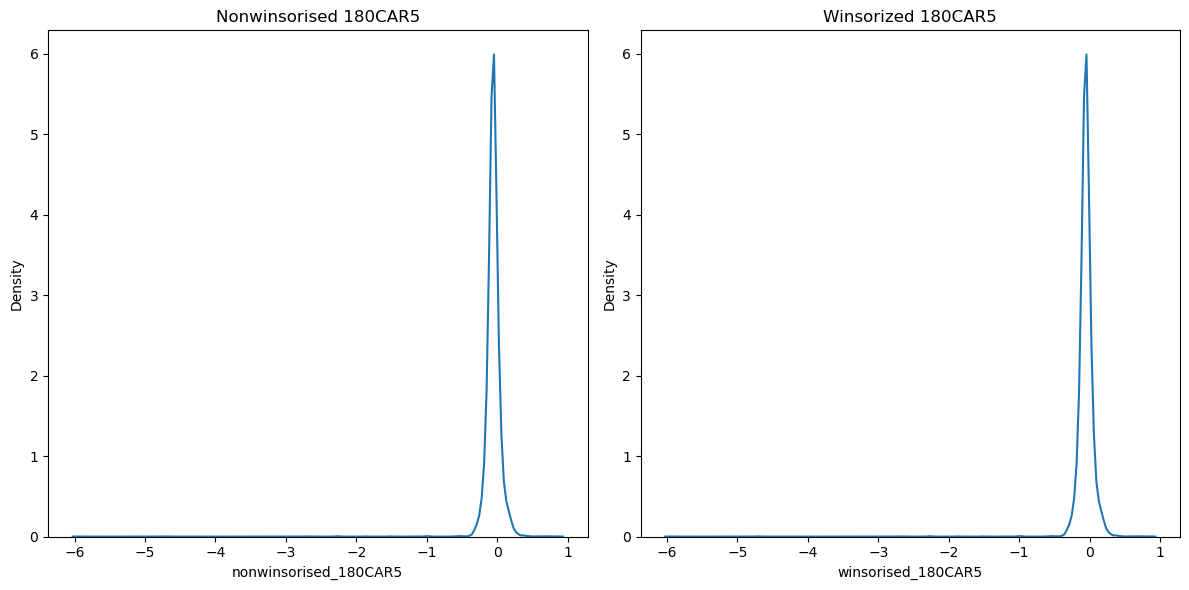

       winsorised_180CAR7  nonwinsorised_180CAR7
count         6488.000000            6488.000000
mean            -0.102972              -0.102972
std              0.156670               0.156670
min             -5.189216              -5.189216
25%             -0.156311              -0.156311
50%             -0.101682              -0.101682
75%             -0.050102              -0.050102
max              1.344630               1.344630


Top values and their count:  nonwinsorised_180CAR7
0.368163    1
0.375596    1
0.392311    1
0.392698    2
0.426058    1
0.507791    1
0.520388    1
0.594831    2
0.659249    1
1.344630    1
Name: count, dtype: int64





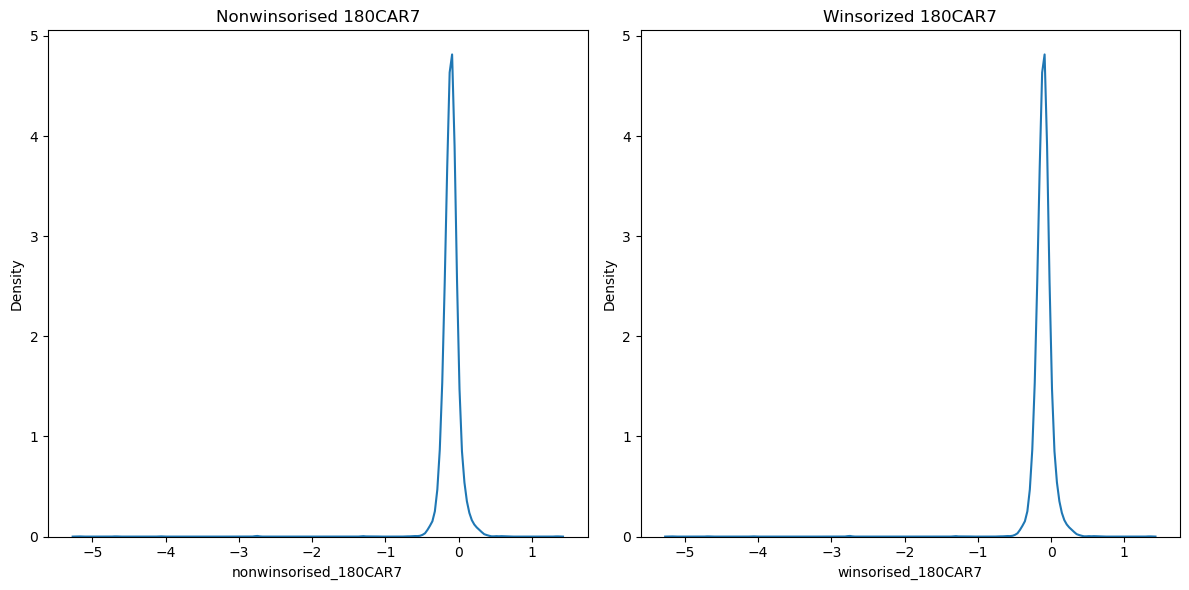

       winsorised_180CAR11  nonwinsorised_180CAR11
count          6479.000000             6479.000000
mean             -0.196988               -0.196988
std               0.188942                0.188942
min              -6.300427               -6.300427
25%              -0.269509               -0.269509
50%              -0.199307               -0.199307
75%              -0.122661               -0.122661
max               2.028564                2.028564


Top values and their count:  nonwinsorised_180CAR11
0.411565    1
0.422918    1
0.425671    2
0.438061    2
0.450776    1
0.512747    1
0.541476    1
0.571859    1
0.801564    1
2.028564    1
Name: count, dtype: int64





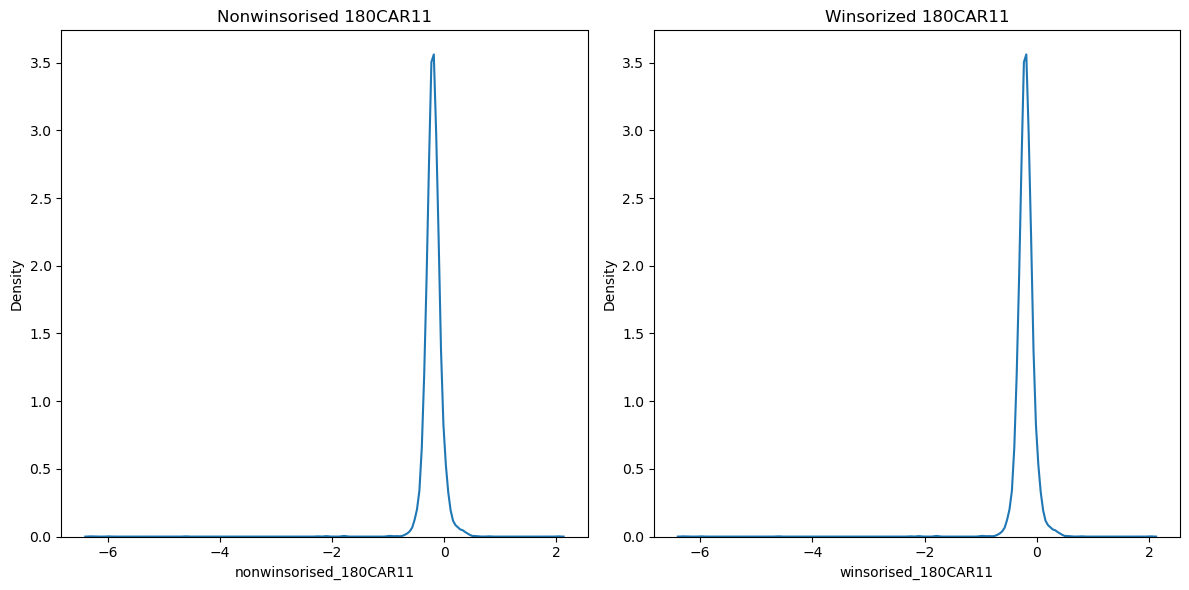

       winsorised_210CAR3  nonwinsorised_210CAR3
count         6464.000000            6464.000000
mean            -0.002752              -0.002752
std              0.100552               0.100552
min             -4.033665              -4.033665
25%             -0.037650              -0.037650
50%             -0.003215              -0.003215
75%              0.031953               0.031953
max              0.635354               0.635354


Top values and their count:  nonwinsorised_210CAR3
0.313695    1
0.323861    2
0.328099    1
0.337160    1
0.368676    1
0.378806    1
0.385350    1
0.514985    1
0.592347    1
0.635354    1
Name: count, dtype: int64





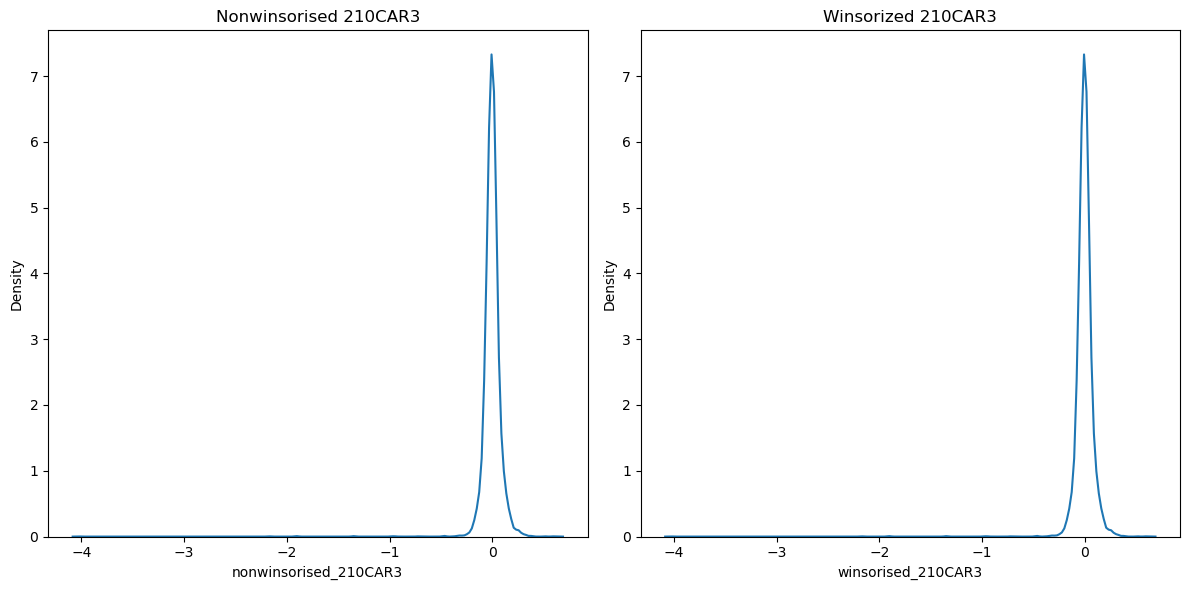

       winsorised_210CAR5  nonwinsorised_210CAR5
count         6462.000000            6462.000000
mean            -0.052964              -0.052964
std              0.129642               0.129642
min             -5.366582              -5.366582
25%             -0.094680              -0.094680
50%             -0.053990              -0.053990
75%             -0.011598              -0.011598
max              0.861614               0.861614


Top values and their count:  nonwinsorised_210CAR5
0.374007    1
0.377939    1
0.390013    1
0.392611    1
0.449998    2
0.545316    1
0.581465    1
0.693191    1
0.737757    1
0.861614    1
Name: count, dtype: int64





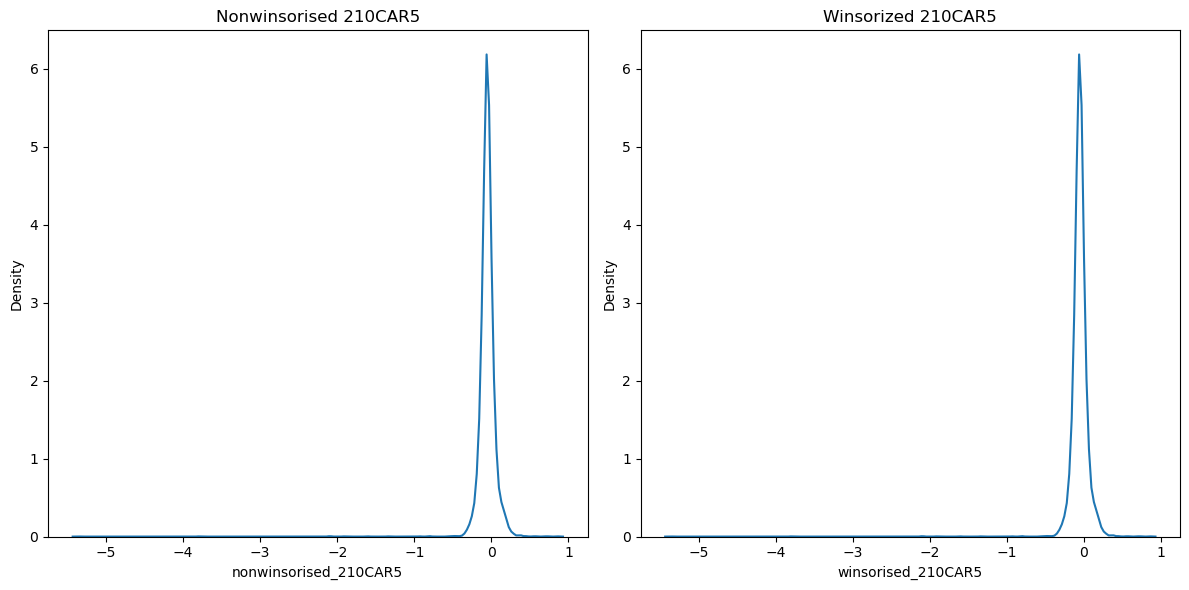

       winsorised_210CAR7  nonwinsorised_210CAR7
count         6460.000000            6460.000000
mean            -0.102086              -0.102086
std              0.143962               0.143962
min             -4.625589              -4.625589
25%             -0.155652              -0.155652
50%             -0.101783              -0.101783
75%             -0.050223              -0.050223
max              1.342183               1.342183


Top values and their count:  nonwinsorised_210CAR7
0.369594    1
0.372917    1
0.382766    1
0.395994    2
0.422798    1
0.507987    1
0.519022    1
0.588774    2
0.694031    1
1.342183    1
Name: count, dtype: int64





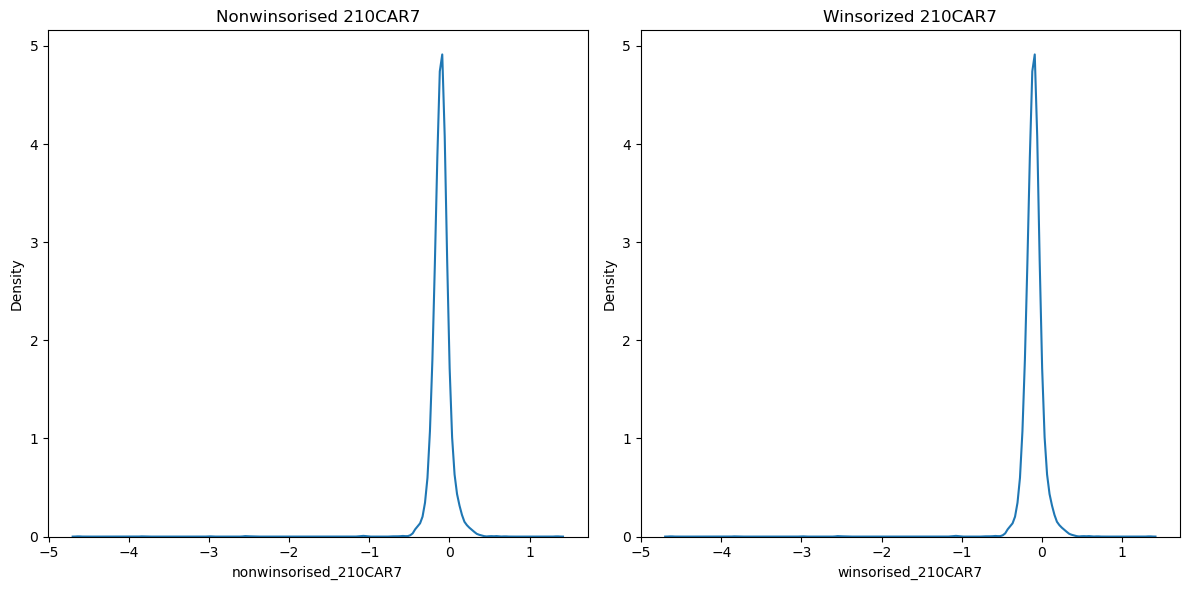

       winsorised_210CAR11  nonwinsorised_210CAR11
count          6451.000000             6451.000000
mean             -0.195692               -0.195692
std               0.171057                0.171057
min              -4.964445               -4.964445
25%              -0.268760               -0.268760
50%              -0.199540               -0.199540
75%              -0.123269               -0.123269
max               2.025149                2.025149


Top values and their count:  nonwinsorised_210CAR11
0.419804    1
0.423046    1
0.440251    2
0.446498    1
0.449964    1
0.510529    1
0.514117    1
0.664695    1
0.785966    1
2.025149    1
Name: count, dtype: int64





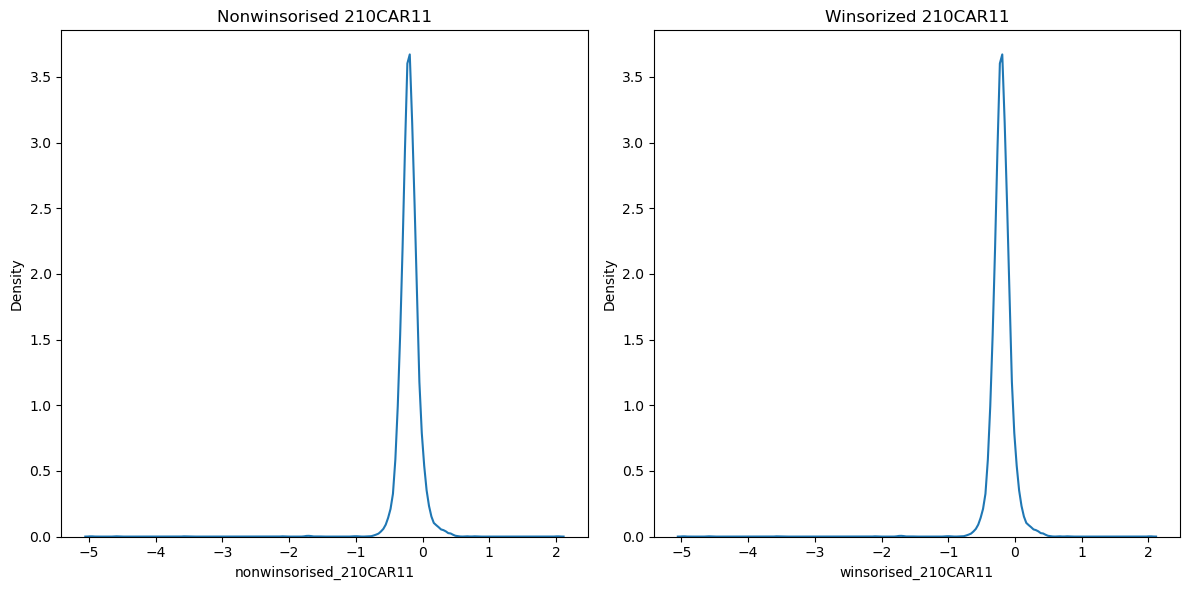

In [10]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

from scipy.stats.mstats import winsorize

def winsorize_output(sample, variable, limits = [0, 0]):
    sample[f"nonwinsorised_{variable}"] = sample[variable]
    sample[f"winsorised_{variable}"] = winsorize(np.array(sample[f"nonwinsorised_{variable}"]), limits = limits, inclusive = [False, False])
    sample[[f"nonwinsorised_{variable}", f"winsorised_{variable}"]].describe()
    print(sample[[f"winsorised_{variable}", f"nonwinsorised_{variable}"]].describe())
    print("\n\nTop values and their count: ", (sample[f"nonwinsorised_{variable}"].value_counts().sort_index().tail(n=10)))
    print("\n\n")
    
    # Graphs
    fig, axes = plt.subplots(1, 2, figsize = (12, 6))
    sns.kdeplot(data = sample[f"nonwinsorised_{variable}"].replace([np.inf, -np.inf], np.nan), ax = axes[0])
    axes[0].set_title(f'Nonwinsorised {variable}')
    sns.kdeplot(data = sample[f"winsorised_{variable}"].replace([np.inf, -np.inf], np.nan), ax = axes[1])
    axes[1].set_title(f'Winsorized {variable}')
    plt.tight_layout()
    plt.show()

    sample[variable] = sample[f"winsorised_{variable}"]
    return sample[variable]

for car in carCol:
    psmSampleIndep[car] = winsorize_output(psmSampleIndep, car, [0, 0])

In [11]:
# controlVars = [
#     "NonpromoterInstitutions_percent", "ln_marcap", "Debt to equity ratio",
    
#     "PC1_FactorScore_Standardised", "ln_dirage", "ln_directorships"
# ]
# filter_datas = []
# CARs = [120, 150, 180, 210]
# for i,CAR in enumerate(CARs):
#     frame = pd. read_pickle(rf"{filtering_folder_path}\Insufficient Data for {CAR}CAR.pkl").rename({"AsOnDate":"Date"}, axis = 1)
#     filter_datas.append(frame)

# carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
#           "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
#           "180CAR3", "180CAR5", "180CAR7", "180CAR11",
#           "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

# print("N for each CAR, no subsampling, dropping for na in control vars + car")

# event_days = [3, 5, 7, 11]

# for i,CAR in enumerate(CARs):
#     frame = psmSampleIndep.merge(filter_datas[i], left_on = ["CompanyName", "Appointment Date"], right_on = ["CompanyName", "Date"], how = "left")
#     for days in event_days:
#         car = f"{CAR}CAR{days}"
#         print(f"{car} N = ", frame.dropna(subset = [car] + controlVars)["na_trading_days"].mean() )

# frame_filtered = frame.dropna(subset=[car] + controlVars)
# frame_filtered["index"] = frame_filtered.index
# frame_filtered.plot(kind="scatter", x="index", y="na_trading_days")

In [12]:
# dirFirm2 = dirFirm.copy()
# psmSampleIndep2 = psmSampleIndep.copy()

# listCol = [
#     "FirstYearPCodeList", "TwoYearPCodeList", "ThreeYearPCodeList", "PCodeList",
#     "FirstYearIndepPCodeList", "TwoYearIndepPCodeList", "ThreeYearIndepPCodeList", "IndepPCodeList",
#     "OtherFirstYearIndepPCode", "OtherTwoYearIndepPCode", "OtherThreeYearIndepPCode", "TotalIndepPCode",
#     "OtherFirstYearPCode", "OtherTwoYearPCode", "OtherThreeYearPCode", "TotalPCode",
#     "OtherFirstYearPCodeIndepExcl","OtherTwoYearPCodeIndepExcl", "OtherThreeYearPCodeIndepExcl", "TotalPCodeIndepExcl",
#     "OtherFirstYearPCodeExcl", "OtherTwoYearPCodeExcl", "OtherThreeYearPCodeExcl", "TotalPCodeExcl"
# ]

# dirFirm2 = dirFirm2.drop(listCol, axis = 1)
# psmSampleIndep2 = psmSampleIndep2.drop(listCol, axis = 1)


# dirFirm2.to_csv("Main_Firm_PSM Ready_no filter v040425.csv")
# psmSampleIndep2.to_csv("Main_Firm_PSM Ready_filter-Indep_gov_fin v040425.csv")


# # # psmSampleAll --> 2101 rows 
# # psmSampleIndep --> 1561 rows 

## PSM --> RookieAppoints as Treatment, NonRookieAppoints as Control

In [13]:
def LogitReg(sample, endog_var, exog_var):
    
    # Logit Regression
    endog = sample[endog_var]
    exog = sample[exog_var]
    
    scaler = StandardScaler()
    exog_standardised = pd.DataFrame(scaler.fit_transform(exog), columns=exog.columns)

    exog_standardised = sm.add_constant(exog_standardised)
    
    log_reg = sm.Logit(endog, exog_standardised).fit()

    propensityScores = log_reg.predict(exog_standardised)
    
    return propensityScores

In [14]:
def MeanDiffTtest(sample, endog_var, exog_var, car, depVar, dirFirm):

    sample[car] = winsorize(sample[car], limits = [0.01, 0.01])
    if depVar != None:
        dirFirm = dirFirm.rename( {depVar:f"{depVar}_2"}, axis = 1)
    
        colsAdd = []
        for i in range(-1, 4):
            if i != 0:
                colsAdd.append(f"AsOnYear_T+{i}")
                colsAdd.append(f"{depVar}T+{i}")
                if i>0 :
                    colsAdd.append(depVar+f"(T+{i}) - (T-1)")
    
        newFrame= pd.DataFrame(columns = colsAdd, data = 0, index = sample.index, dtype = "float")
        sample = pd.concat([sample, newFrame], axis = 1)
        sample = sample.copy()
        
        for i in range(-1, 4):
            if i != 0:
                sample.loc[:, f"AsOnYear_T+{i}"] = sample["AsOnYear"] + i
    
        for i in range(-1, 4):
            if i != 0:
                sample.loc[:, f"{depVar}T+{i}"] = sample.merge(dirFirm[["Symbol", "AsOnYear", f"{depVar}_2"]].copy(), left_on = ["Symbol", f"AsOnYear_T+{i}"],
                                                              right_on = ["Symbol", "AsOnYear"], how = "left")[f"{depVar}_2"]
        
        for i in range(1, 4):
            if i != 0:
                sample.loc[:, depVar+f"(T+{i}) - (T-1)"] = sample[f"{depVar}T+{i}"] - sample[f"{depVar}T+-1"]
    
            
        sample = sample.copy()
    
    group1 = sample.loc[ sample[endog_var] == 1].copy()
    group2 = sample.loc[ sample[endog_var] == 0].copy()
    
    t_stat, p_value = stats.ttest_ind(group1[car], group2[car], equal_var=False)  # Welch’s t-test (default)

    print("\n")
    print(car, ":")
    print("\n")
    print("T Statistic:", t_stat, " P Value:",p_value)
    print("Treated Mean:", group1[car].mean(), " Control Mean:", group2[car].mean(), " Diff:", group1[car].mean() - group2[car].mean())
    print("Treated Median:", group1[car].median(), " Control Median:", group2[car].median(), " Diff:", group1[car].median() - group2[car].median())
    print("Treated N:", len(group1[car]), "; Control N:", len(group2[car]))
    print("[treated unique = ", len(group1.loc[ :, ["Person Code", "Symbol", "AsOnDate"]].drop_duplicates()), "]",\
          "[control unique = ", len(group2.loc[ :, ["Person Code", "Symbol", "AsOnDate"]].drop_duplicates()), "]"
         )
    print("\n")

    # -----------------------------------------------------------------------------------------------------------------
    
    if exog_var != None:
        print("━"*120)
        print(f'{"Matching Variable":<40} {"Treatment":<20} {"Control":<20} {"SMD":<20}')
        print(f'{" ":<40} {"N = " + str(len(group1[car])):<20} {"N = " + str(len(group2[car])):<20}')
        print("-"*120)

        for var in exog_var:
            treatMean = group1[var].mean()
            controlMean = group2[var].mean()
            # p_value = stats.ttest_ind(group1[var], group2[var], equal_var=False)[1]
            smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
            print(f'{var:<40} {treatMean:<20.4f} {controlMean:<20.4f} {smd:<20.4f}')
    
        print("━"*120, "\n")
    
    # -----------------------------------------------------------------------------------------------------------------


    if depVar != None:
        print(depVar, " across years:\n")
        for i in range(1,4):
            sample = sample.dropna(subset = [depVar+f'(T+{i}) - (T-1)'])
    
        group1 = sample.loc[ sample[endog_var] == 1].copy()
        group2 = sample.loc[ sample[endog_var] == 0].copy()

        print("━"*150, "\n")
        print(f'{depVar:<40}{" ":<20}{"Treatment Firms":<20}{"Control Firms":<20}{"Difference":<20}{"Test of Diff":<20}{"Test of Diff"}')
        print(f'{" ":<120}{"(t stat)":<20}{"(p value)":<20}')
    
        print("─"*150, "\n")
    
        for i in range(1,4):
            t_stat2, p_value2 = stats.ttest_ind(group1[depVar+f'(T+{i}) - (T-1)'], group2[depVar+f'(T+{i}) - (T-1)'], equal_var=False)  # Welch’s t-test (default)
            
            treatedMean = group1[depVar+f'(T+{i}) - (T-1)'].mean()
            controlMean = group2[depVar+f'(T+{i}) - (T-1)'].mean()
            diffMean = treatedMean - controlMean
    
            treatedMedian = group1[depVar+f'(T+{i}) - (T-1)'].median()
            controlMedian = group2[depVar+f'(T+{i}) - (T-1)'].median()
            diffMedian = treatedMedian - controlMedian
    
            print(f'{"Year_T+" + str(i) +" - Year_T-1":<40}{"<MEAN>":<20}{treatedMean:<20.4f}{controlMean:<20.4f}{diffMean:<20.4f}{t_stat2:<20.4f}{p_value2:<20.10f}')
    
            label1 = "Treated N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
            label2 = "Control N: " + str(len(group2[depVar+f'(T+{i}) - (T-1)']))
            
            print(f'{label1 + " "*5 + label2:<40}{"<MEDIAN>":<20}{treatedMedian:<20.4f}{controlMedian:<20.4f}{diffMedian:<20.4f}')
            
            print("-"*150, "\n")
            
        print("━"*150, "\n")

    return

In [15]:
def OneSampleTtest(sample, endog_var, exog_var, car, depVar, dirFirm):

    # if depVar != None:
    #     dirFirm = dirFirm.rename( {depVar:f"{depVar}_2"}, axis = 1)
    
    #     colsAdd = []
    #     for i in range(-1, 4):
    #         if i != 0:
    #             colsAdd.append(f"AsOnYear_T+{i}")
    #             colsAdd.append(f"{depVar}T+{i}")
    #             if i>0 :
    #                 colsAdd.append(depVar+f"(T+{i}) - (T-1)")
    
    #     newFrame= pd.DataFrame(columns = colsAdd, data = 0, index = sample.index, dtype = "int")
    #     sample = pd.concat([sample, newFrame], axis = 1)
    #     sample = sample.copy()
        
    #     for i in range(-1, 4):
    #         if i != 0:
    #             sample.loc[:, f"AsOnYear_T+{i}"] = sample["AsOnYear"] + i
    
    #     for i in range(-1, 4):
    #         if i != 0:
    #             sample.loc[:, f"{depVar}T+{i}"] = sample.merge(dirFirm[["Symbol", "AsOnYear", f"{depVar}_2"]].copy(), left_on = ["Symbol", f"AsOnYear_T+{i}"],
    #                                                           right_on = ["Symbol", "AsOnYear"], how = "left")[f"{depVar}_2"]
        
    #     for i in range(1, 4):
    #         if i != 0:
    #             sample.loc[:, depVar+f"(T+{i}) - (T-1)"] = sample[f"{depVar}T+{i}"] - sample[f"{depVar}T+-1"]
    
            
    #     sample = sample.copy()
    sample[car] = winsorize(sample[car], limits = [0.01, 0.01])
    group1 = sample.copy()
    
    t_stat, p_value = stats.ttest_1samp(group1[car], 0)  # Welch’s t-test (default)
    
    print("\n")
    print(car, ":")
    print("\n")
    print("T Statistic:", t_stat, " P Value:",p_value)
    print("Mean:", group1[car].mean())
    print("Median:", group1[car].median())
    print("N:", len(group1[car]))

    print("\n")

    # -----------------------------------------------------------------------------------------------------------------




    # if exog_var != None:
    #     print("━"*120)
    #     print(f'{"Matching Variable":<40} {"Treatment Firms":<20} {"Control Firms":<20} {"Test of Diff (p value)":<20}')
    #     print(f'{" ":<40} {"N = " + str(len(group1[car])):<20} {"N = " + str(len(group2[car])):<20}')
    #     print("-"*120)

    #     for var in exog_var:
    #         treatMean = group1[var].mean()
    #         controlMean = group2[var].mean()
    #         p_value = stats.ttest_ind(group1[var], group2[var], equal_var=False)[1]
    #         print(f'{var:<40} {treatMean:<20.4f} {controlMean:<20.4f} {p_value:<20.4f}')
    
    #     print("━"*120, "\n")
    
    # -----------------------------------------------------------------------------------------------------------------


    # if depVar != None:
    #     print(depVar, " across years:\n")
    #     for i in range(1,4):
    #         sample = sample.dropna(subset = [depVar+f'(T+{i}) - (T-1)'])
    
    #     group1 = sample.loc[ sample[endog_var] == 1].copy()
    #     group2 = sample.loc[ sample[endog_var] == 0].copy()

    #     print("━"*150, "\n")
    #     print(f'{depVar:<40}{" ":<20}{"Treatment Firms":<20}{"Control Firms":<20}{"Difference":<20}{"Test of Diff":<20}{"Test of Diff"}')
    #     print(f'{" ":<120}{"(t stat)":<20}{"(p value)":<20}')
    
    #     print("─"*150, "\n")
    
    #     for i in range(1,4):
    #         t_stat2, p_value2 = stats.ttest_ind(group1[depVar+f'(T+{i}) - (T-1)'], group2[depVar+f'(T+{i}) - (T-1)'], equal_var=False)  # Welch’s t-test (default)
            
    #         treatedMean = group1[depVar+f'(T+{i}) - (T-1)'].mean()
    #         controlMean = group2[depVar+f'(T+{i}) - (T-1)'].mean()
    #         diffMean = treatedMean - controlMean
    
    #         treatedMedian = group1[depVar+f'(T+{i}) - (T-1)'].median()
    #         controlMedian = group2[depVar+f'(T+{i}) - (T-1)'].median()
    #         diffMedian = treatedMedian - controlMedian
    
    #         print(f'{"Year_T+" + str(i) +" - Year_T-1":<40}{"<MEAN>":<20}{treatedMean:<20.4f}{controlMean:<20.4f}{diffMean:<20.4f}{t_stat2:<20.4f}{p_value2:<20.10f}')
    
    #         label1 = "Treated N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
    #         label2 = "Control N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
            
    #         print(f'{label1 + " "*5 + label2:<40}{"<MEDIAN>":<20}{treatedMedian:<20.4f}{controlMedian:<20.4f}{diffMedian:<20.4f}')
            
    #         print("-"*150, "\n")
            
    #print("━"*150, "\n")

    return

In [16]:
def PsmReplac(sample, endog_var, exog_var, car, depVar, dirFirm):

    # Logit Regression
    sample.loc[:, "propensityScore"] = LogitReg(sample, endog_var, exog_var)

    treated = sample.loc[ sample[endog_var] == 1].copy()
    control = sample.loc[ sample[endog_var] == 0].copy()

    # Nearest Neighbours
    nn = NearestNeighbors(n_neighbors = 1, metric = "euclidean")
    nn.fit(control[["propensityScore"]])

    distances, indices = nn.kneighbors(treated[["propensityScore"]])
    
    matchedControl = control.iloc[indices.flatten()].copy()
    
    matched = pd.concat([treated, matchedControl])
    matched.reset_index(drop=True, inplace=True)

    MeanDiffTtest(matched, endog_var, exog_var, car, depVar, dirFirm)

    return

In [17]:
# Func PSM non replacement
def PsmNonReplac(sample, endog_var, exog_var, car, depVar, dirFirm):

    # Logit Regression
    sample.loc[:, "propensityScore"] = LogitReg(sample, endog_var, exog_var)

    # Separate treated and control groups
    treated = sample[sample[endog_var] == 1].copy()
    control = sample[sample[endog_var] == 0].copy()
    
    # Compute pairwise distances (absolute difference in propensity scores)
    dist_matrix = cdist(treated[['propensityScore']], control[['propensityScore']], metric='euclidean')
    
    # Match without replacement
    treated_indices = []
    matched_indices = []
    used_control_indices = set()
    
    for i in range(len(treated)):
        if len(used_control_indices) >= len(control):  # Stop if no controls left
            print("Warning: Not enough control units to match all treated units.")
            break
        
        # Get nearest control unit index that hasn't been used
        match_idx = np.argmin(dist_matrix[i])
        
        while match_idx in used_control_indices:  # Ensure it's not already matched
            dist_matrix[i, match_idx] = np.inf  # Temporarily set distance to infinity

            if np.all(dist_matrix[i] == np.inf):  # If all controls are exhausted
                print(f"No available control for treated unit {i}, skipping.")
                match_idx = None
                break
            
            match_idx = np.argmin(dist_matrix[i])
        
        used_control_indices.add(match_idx)
        matched_indices.append(match_idx)
        treated_indices.append(i)
    
    # Retrieve matched units
    matched_control = control.iloc[matched_indices].copy()
    matched_treated = treated.iloc[treated_indices].copy()
    
    # Combine matched treated and control units
    matched_data = pd.concat([matched_treated.reset_index(drop=True), matched_control.reset_index(drop=True)])
    
    # Reset index
    matched_data.reset_index(drop=True, inplace=True)


    # Mean difference and T Test
    MeanDiffTtest(matched_data, endog_var, exog_var, car, depVar, dirFirm)

    return
    


In [18]:
def prep_sample(sample, car, controlVars, yearDummy = 0, industryDummy = 0) -> tuple[pd.DataFrame, list[str]]:
    
    sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)

    if yearDummy == 1:
        yearDummies = pd.get_dummies( sample["AsOnYear"], prefix = "YearDummy_", drop_first = True, dtype = "int")
        dummiesWithOnlyOneFirm = yearDummies.sum().loc[ yearDummies.sum() == 1 ].index.values
        yearDummies.drop(dummiesWithOnlyOneFirm, axis = 1, inplace = True)
        sample = pd.concat([sample, yearDummies], axis = 1)
    else:
        yearDummies = pd.DataFrame()
    
    if industryDummy == 1:
        industryDummies = pd.get_dummies( sample["NIC_1digit"], prefix = "IndustryDummy_", drop_first = True, dtype = "int")
        dummiesWithOnlyOneFirm = industryDummies.sum().loc[ industryDummies.sum() == 1 ].index.values
        industryDummies.drop(dummiesWithOnlyOneFirm, axis = 1, inplace = True)
        sample = pd.concat([sample, industryDummies], axis = 1)
    else:
        industryDummies = pd.DataFrame()

    exog_var = controlVars + yearDummies.columns.to_list() + industryDummies.columns.to_list()

    # checking for multicollinearity
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    from statsmodels.tools.tools import add_constant
    exog_with_const = add_constant(sample[exog_var])
    
    vif_data = pd.DataFrame()
    vif_data["feature"] = exog_with_const.columns
    vif_data["VIF"] = [variance_inflation_factor(exog_with_const.values, i)
                       for i in range(exog_with_const.shape[1])]
    highCollinearity = [x for x in 
                    vif_data.loc[ vif_data["VIF"] > 10 ]["feature"].values
                    if x!="const"]
    exog_var = [x for x in exog_var if x not in highCollinearity]    
    
    return sample, exog_var

# PSM on PCA output + other controls

In [19]:
controlVars = ["PercentWomenDir", "PercentBusyDir",
               "LnBoardSize", "PercentIndep",
               "Promoters_percent", "NonpromoterInstitutions_percent",
               "ln_marcap", "ln_rdtoassets", "Debt to equity ratio"]

# controlVars = [
#     "NonpromoterInstitutions_percent", "ln_marcap", "Debt to equity ratio",
    
#     "Skilllist_FactorScore", "ln_dirage", "ln_directorships"
# ]

#PsmReplac(sample, endog_var, exog_var, car, depVar, dirFirm)

# No Higher level Filtration

## Version 0: No filtration

## No fixed effects

### PSM with replacement

In [20]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None



for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.560285
         Iterations 5


120CAR3 :


T Statistic: -1.302235445825123  P Value: 0.19287773062233332
Treated Mean: -0.0006057417122953399  Control Mean: 0.0013673023213861418  Diff: -0.001973044033681482
Treated Median: -0.0031791012435223656  Control Median: -0.005266028358620792  Diff: 0.002086927115098426
Treated N: 3593 ; Control N: 3593
[treated unique =  3593 ] [control unique =  1026 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 3593             N = 3593            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1714               0.1759               -0.0468      

## Using Year fixed effects

### PSM with replacement

In [21]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.554634
         Iterations 6


120CAR3 :


T Statistic: 1.7067821632953117  P Value: 0.0879057709941128
Treated Mean: -0.0008176352755915924  Control Mean: -0.0034833802438109327  Diff: 0.00266574496821934
Treated Median: -0.0031791012435223656  Control Median: -0.004320483376622334  Diff: 0.0011413821330999684
Treated N: 3593 ; Control N: 3593
[treated unique =  3593 ] [control unique =  1018 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 3593             N = 3593            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1714               0.1786               -0.0709       

## Using Year + Industry fixed effects

### PSM with replacement

In [22]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.553977
         Iterations 6


120CAR3 :


T Statistic: -0.4238697802133055  P Value: 0.6716734882324024
Treated Mean: -0.00012299045936829865  Control Mean: 0.0005524753009712089  Diff: -0.0006754657603395075
Treated Median: -0.0031791012435223656  Control Median: -0.0059211848460229005  Diff: 0.002742083602500535
Treated N: 3593 ; Control N: 3593
[treated unique =  3593 ] [control unique =  1012 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 3593             N = 3593            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1714               0.1809               -0.0948   

In [23]:
# sample0 = psmSampleIndepWithYearIndustryDummies0.replace([np.inf, -np.inf], pd.NA).copy()
# exog_var = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
# sample = sample0.dropna(subset = [car] + exog_var).reset_index(drop=True).copy()
# sample[exog_var].T[sample[exog_var].T.duplicated(keep = False) == True ].index
# sample.describe()

# Version 1: promoterholding25==1 & hasfamilychairmanandceo==1

In [24]:
psmSampleIndep1 = psmSampleIndep.loc[ (psmSampleIndep["promoterholding25"]==1) & (psmSampleIndep["HasFamilyChairmanAndCEO"]==1) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [25]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", controlVars, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.544540
         Iterations 6


120CAR3 :


T Statistic: -1.884331786757339  P Value: 0.0596266984063699
Treated Mean: -0.0007444875911801772  Control Mean: 0.003945195381362599  Diff: -0.004689682972542776
Treated Median: -0.0032539445229751718  Control Median: 0.003516407869088148  Diff: -0.00677035239206332
Treated N: 1368 ; Control N: 1368
[treated unique =  1368 ] [control unique =  376 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 1368             N = 1368            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1732               0.1823               -0.0967          

## Using Year fixed effects

### PSM with replacement

In [26]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.536077
         Iterations 6


120CAR3 :


T Statistic: -0.08973540836212125  P Value: 0.92850412087527
Treated Mean: -0.0008383640251309144  Control Mean: -0.0006189051469240248  Diff: -0.00021945887820688955
Treated Median: -0.0032539445229751718  Control Median: -0.00044708682221296717  Diff: -0.0028068577007622046
Treated N: 1368 ; Control N: 1368
[treated unique =  1368 ] [control unique =  366 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 1368             N = 1368            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1732               0.1803               -0.0752 

## Using Year + Industry fixed effects

### PSM with replacement

In [27]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.535124
         Iterations 6


120CAR3 :


T Statistic: -0.793068775265179  P Value: 0.4278073869373388
Treated Mean: -0.0003676037140132481  Control Mean: 0.0015988626078826359  Diff: -0.001966466321895884
Treated Median: -0.0032539445229751718  Control Median: -0.0009432600447044567  Diff: -0.002310684478270715
Treated N: 1368 ; Control N: 1368
[treated unique =  1368 ] [control unique =  373 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 1368             N = 1368            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1732               0.1773               -0.0444      

# Version 2: promoterholding25==1 & hasfamilychairmanandceo==0

In [28]:
psmSampleIndep2 = psmSampleIndep.loc[ (psmSampleIndep["promoterholding25"]==1) & (psmSampleIndep["HasFamilyChairmanAndCEO"]==0) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [29]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.572575
         Iterations 5


120CAR3 :


T Statistic: 0.22280280306452202  P Value: 0.8237002968482349
Treated Mean: -0.0001125771683187733  Control Mean: -0.0005514019989855109  Diff: 0.00043882483066673764
Treated Median: -0.0031791012435223656  Control Median: -0.00600535930589316  Diff: 0.002826258062370794
Treated N: 2021 ; Control N: 2021
[treated unique =  2021 ] [control unique =  621 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 2021             N = 2021            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1702               0.1751               -0.0500      

## Using Year fixed effects

### PSM with replacement

In [30]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.566480
         Iterations 5


120CAR3 :


T Statistic: 1.7265556862466145  P Value: 0.08432395600024678
Treated Mean: -3.561993319933617e-05  Control Mean: -0.00351861047883803  Diff: 0.003482990545638694
Treated Median: -0.0031791012435223656  Control Median: -0.007426175310044379  Diff: 0.004247074066522014
Treated N: 2021 ; Control N: 2021
[treated unique =  2021 ] [control unique =  596 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 2021             N = 2021            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1702               0.1730               -0.0286         

## Using Year + Industry fixed effects

### PSM with replacement

In [31]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.564721
         Iterations 5


120CAR3 :


T Statistic: 1.3038798181179874  P Value: 0.19234966251164326
Treated Mean: 0.0002920526583473577  Control Mean: -0.002609205745586887  Diff: 0.0029012584039342444
Treated Median: -0.0031791012435223656  Control Median: -0.011767711147049317  Diff: 0.008588609903526952
Treated N: 2021 ; Control N: 2021
[treated unique =  2021 ] [control unique =  589 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 2021             N = 2021            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1702               0.1635               0.0711         

In [32]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

# Higher level Filteration: DUPLICATED DIRECTORS REMOVED

## Version 0: No filtration

In [33]:
# psmSampleIndep0 = psmSampleIndep.copy()

# yearDummies0 = pd.get_dummies( psmSampleIndep0["AsOnYear"], prefix = "YearDummy_", drop_first = True, dtype = "int")
# psmSampleIndepWithYearDummies0 = pd.concat([psmSampleIndep0, yearDummies0], axis = 1)

# industryDummies0 = pd.get_dummies( psmSampleIndep0["NIC_2digit"], prefix = "IndustryDummy_", drop_first = True, dtype = "int")
# psmSampleIndepWithYearIndustryDummies0 = pd.concat([psmSampleIndepWithYearDummies0, industryDummies0], axis = 1)

# depVar = None

In [34]:
duplicated = psmSampleIndep.duplicated(subset = ["Symbol", "Appointment Date"], keep = False).to_frame("val")
filtered_index = duplicated.loc[duplicated["val"] == False].index
psmSampleIndep_filtered = psmSampleIndep.loc[filtered_index].copy()

## No fixed effects

### PSM with replacement

In [35]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None



for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep_filtered, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.564138
         Iterations 5


120CAR3 :


T Statistic: -1.2707270955923309  P Value: 0.20388065485923662
Treated Mean: -0.00019168106444183096  Control Mean: 0.002042172680365939  Diff: -0.00223385374480777
Treated Median: -0.002941299747032458  Control Median: 0.00019915403933146864  Diff: -0.0031404537863639267
Treated N: 2701 ; Control N: 2701
[treated unique =  2701 ] [control unique =  823 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 2701             N = 2701            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1726               0.1764               -0.0394     

## Using Year fixed effects

### PSM with replacement

In [36]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep_filtered, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.554364
         Iterations 6


120CAR3 :


T Statistic: -2.8556822143257885  P Value: 0.004311033737456585
Treated Mean: 0.0003669379962922516  Control Mean: 0.005930518965733374  Diff: -0.005563580969441123
Treated Median: -0.002941299747032458  Control Median: 0.0004006165987243543  Diff: -0.0033419163457568124
Treated N: 2701 ; Control N: 2701
[treated unique =  2701 ] [control unique =  798 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 2701             N = 2701            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1726               0.1738               -0.0121      

## Using Year + Industry fixed effects

### PSM with replacement

In [37]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep_filtered, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.552877
         Iterations 6


120CAR3 :


T Statistic: -4.04147461756318  P Value: 5.3860180657465376e-05
Treated Mean: 0.0001249746199684916  Control Mean: 0.00793710144543741  Diff: -0.007812126825468918
Treated Median: -0.002941299747032458  Control Median: 0.0030679862206033914  Diff: -0.0060092859676358495
Treated N: 2701 ; Control N: 2701
[treated unique =  2701 ] [control unique =  811 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 2701             N = 2701            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1726               0.1715               0.0123        

In [38]:
# sample0 = psmSampleIndepWithYearIndustryDummies0.replace([np.inf, -np.inf], pd.NA).copy()
# exog_var = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
# sample = sample0.dropna(subset = [car] + exog_var).reset_index(drop=True).copy()
# sample[exog_var].T[sample[exog_var].T.duplicated(keep = False) == True ].index
# sample.describe()

# Version 1: promoterholding25==1 & hasfamilychairmanandceo==1

In [39]:
psmSampleIndep1 = psmSampleIndep_filtered.loc[ (psmSampleIndep_filtered["promoterholding25"]==1) & (psmSampleIndep_filtered["HasFamilyChairmanAndCEO"]==1) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [40]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", controlVars, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.553975
         Iterations 5


120CAR3 :


T Statistic: -2.614689706957536  P Value: 0.008994184831192117
Treated Mean: -0.0017672363936322402  Control Mean: 0.006420940115362699  Diff: -0.00818817650899494
Treated Median: -0.0033733864710418504  Control Median: 0.0032159335040666676  Diff: -0.006589319975108518
Treated N: 1060 ; Control N: 1060
[treated unique =  1060 ] [control unique =  311 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 1060             N = 1060            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1737               0.1809               -0.0781       

## Using Year fixed effects

### PSM with replacement

In [41]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.538463
         Iterations 6


120CAR3 :


T Statistic: -2.613585502296148  P Value: 0.009023953156738509
Treated Mean: -0.0015807826395721888  Control Mean: 0.006158870004330731  Diff: -0.00773965264390292
Treated Median: -0.0033733864710418504  Control Median: 0.0052213359160440675  Diff: -0.008594722387085918
Treated N: 1060 ; Control N: 1060
[treated unique =  1060 ] [control unique =  303 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 1060             N = 1060            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1737               0.1843               -0.1101       

## Using Year + Industry fixed effects

### PSM with replacement

In [42]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.536480
         Iterations 6


120CAR3 :


T Statistic: 0.1660805303916689  P Value: 0.8681097174005263
Treated Mean: -0.0016635678282514814  Control Mean: -0.0021477376297636967  Diff: 0.00048416980151221533
Treated Median: -0.0033733864710418504  Control Median: 0.0023756860084592907  Diff: -0.005749072479501141
Treated N: 1060 ; Control N: 1060
[treated unique =  1060 ] [control unique =  295 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 1060             N = 1060            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1737               0.1838               -0.1055     

# Version 2: promoterholding25==1 & hasfamilychairmanandceo==0

In [43]:
psmSampleIndep2 = psmSampleIndep_filtered.loc[ (psmSampleIndep_filtered["promoterholding25"]==1) & (psmSampleIndep_filtered["HasFamilyChairmanAndCEO"]==0) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [44]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.571754
         Iterations 5


120CAR3 :


T Statistic: 1.6733286109245091  P Value: 0.09436763403301673
Treated Mean: 0.0006452686375268169  Control Mean: -0.00306833823066271  Diff: 0.003713606868189527
Treated Median: -0.0024460827917813163  Control Median: -0.007426175310044379  Diff: 0.004980092518263063
Treated N: 1500 ; Control N: 1500
[treated unique =  1500 ] [control unique =  459 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 1500             N = 1500            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1728               0.1803               -0.0732          

## Using Year fixed effects

### PSM with replacement

In [45]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.563329
         Iterations 5


120CAR3 :


T Statistic: 0.6619681720787048  P Value: 0.5080425264499318
Treated Mean: 0.0005702239122368387  Control Mean: -0.0009869037945749943  Diff: 0.001557127706811833
Treated Median: -0.0024460827917813163  Control Median: -0.00381844862629618  Diff: 0.0013723658345148639
Treated N: 1500 ; Control N: 1500
[treated unique =  1500 ] [control unique =  471 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 1500             N = 1500            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1728               0.1781               -0.0534         

## Using Year + Industry fixed effects

### PSM with replacement

In [46]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.561092
         Iterations 6


120CAR3 :


T Statistic: -3.106788125476645  P Value: 0.001909455626116168
Treated Mean: 0.0010312557779979122  Control Mean: 0.009094742728647826  Diff: -0.008063486950649913
Treated Median: -0.0024460827917813163  Control Median: 0.001412441166846315  Diff: -0.0038585239586276313
Treated N: 1500 ; Control N: 1500
[treated unique =  1500 ] [control unique =  470 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 1500             N = 1500            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1728               0.1636               0.0979        

In [47]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

# Version 3: Non family firms promoterholding25==0 & hasfamilychairmanandceo==0

In [48]:
psmSampleIndep3 = psmSampleIndep_filtered.loc[ (psmSampleIndep_filtered["promoterholding25"]==0) & (psmSampleIndep_filtered["HasFamilyChairmanAndCEO"]==0) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [49]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.569963
         Iterations 6


120CAR3 :


T Statistic: 0.32853420208913997  P Value: 0.74287293651124
Treated Mean: 0.004587273946621187  Control Mean: 0.0018860125491907123  Diff: 0.0027012613974304748
Treated Median: -0.003426329024861969  Control Median: 0.0009392819924793246  Diff: -0.0043656110173412935
Treated N: 96 ; Control N: 96
[treated unique =  96 ] [control unique =  28 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 96               N = 96              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1598               0.1531               0.0737              
Per

## Using Year fixed effects

### PSM with replacement

In [50]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.490829
         Iterations: 35


120CAR3 :


T Statistic: 1.1433776767231056  P Value: 0.2543452327142959
Treated Mean: 0.004587273946621187  Control Mean: -0.005002924548190416  Diff: 0.009590198494811603
Treated Median: -0.003426329024861969  Control Median: 0.0009392819924793246  Diff: -0.0043656110173412935
Treated N: 96 ; Control N: 96
[treated unique =  96 ] [control unique =  25 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 96               N = 96              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1598               0.1906               -0.3430             
PercentBusyDir                         

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[treated unique =  96 ] [control unique =  25 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 96               N = 96              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1598               0.1906               -0.3430             
PercentBusyDir                           0.2639               0.2648               -0.0028             
LnBoardSize                              2.2611               2.2464               0.0456              
PercentIndep                             0.5464               0.5489               -0.0230             
Promoters_percent                        15.5409              15.5898              -0.0073             
N

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.490829
         Iterations: 35


150CAR11 :


T Statistic: -1.7534203198773992  P Value: 0.08148544321737176
Treated Mean: -0.19623849046610098  Control Mean: -0.16444617581653836  Diff: -0.031792314649562614
Treated Median: -0.2029572980866285  Control Median: -0.14068202661604473  Diff: -0.06227527147058376
Treated N: 96 ; Control N: 96
[treated unique =  96 ] [control unique =  25 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 96               N = 96              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1598               0.1906               -0.3430             
PercentBusyDir                           

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.490738
         Iterations: 35


180CAR3 :


T Statistic: 1.4510125477726168  P Value: 0.1485743483564797
Treated Mean: 0.004349595886278728  Control Mean: -0.009110233066856627  Diff: 0.013459828953135355
Treated Median: -0.0029011825672766584  Control Median: -0.015078948981669955  Diff: 0.012177766414393297
Treated N: 95 ; Control N: 95
[treated unique =  95 ] [control unique =  23 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 95               N = 95              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1603               0.1759               -0.1752             
PercentBusyDir                          

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.490738
         Iterations: 35


210CAR7 :


T Statistic: 0.7729080263255625  P Value: 0.44055033449697
Treated Mean: -0.09087967726320001  Control Mean: -0.10325873519713906  Diff: 0.01237905793393905
Treated Median: -0.09123905992368955  Control Median: -0.08274460420116991  Diff: -0.00849445572251964
Treated N: 95 ; Control N: 95
[treated unique =  95 ] [control unique =  23 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 95               N = 95              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1603               0.1759               -0.1752             
PercentBusyDir                           0.2667

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Using Year + Industry fixed effects

### PSM with replacement

In [51]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.485596
         Iterations: 35


120CAR3 :


T Statistic: 0.8408253824231967  P Value: 0.4015748921694713
Treated Mean: 0.004587273946621187  Control Mean: -0.0030610349409196714  Diff: 0.007648308887540858
Treated Median: -0.003426329024861969  Control Median: 0.0009392819924793246  Diff: -0.0043656110173412935
Treated N: 96 ; Control N: 96
[treated unique =  96 ] [control unique =  26 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 96               N = 96              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1598               0.1699               -0.1054             
PercentBusyDir                        

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.485596
         Iterations: 35


120CAR5 :


T Statistic: 0.023500062607661364  P Value: 0.9812763459167575
Treated Mean: -0.04327088109787844  Control Mean: -0.043552245542105406  Diff: 0.00028136444422696694
Treated Median: -0.044625135150351734  Control Median: -0.022036116975858694  Diff: -0.02258901817449304
Treated N: 96 ; Control N: 96
[treated unique =  96 ] [control unique =  26 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 96               N = 96              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1598               0.1699               -0.1054             
PercentBusyDir                       

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.485596
         Iterations: 35


120CAR7 :


T Statistic: -0.6355136082288645  P Value: 0.5258746427821193
Treated Mean: -0.09009192093634832  Control Mean: -0.0802455451812268  Diff: -0.009846375755121525
Treated Median: -0.09070808445944682  Control Median: -0.06728157394717887  Diff: -0.023426510512267948
Treated N: 96 ; Control N: 96
[treated unique =  96 ] [control unique =  26 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 96               N = 96              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1598               0.1699               -0.1054             
PercentBusyDir                           0

...

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.485428
         Iterations: 35


180CAR11 :


T Statistic: -1.1470481639681802  P Value: 0.2530045199908588
Treated Mean: -0.19907202276026778  Control Mean: -0.1770461206088919  Diff: -0.02202590215137587
Treated Median: -0.21051203361148293  Control Median: -0.1318236435749771  Diff: -0.07868839003650582
Treated N: 95 ; Control N: 95
[treated unique =  95 ] [control unique =  26 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 95               N = 95              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1603               0.1810               -0.2108             
PercentBusyDir                           0.2

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "




210CAR5 :


T Statistic: 1.2718002731891125  P Value: 0.20507424824447082
Treated Mean: -0.04324452295417393  Control Mean: -0.05831915837566981  Diff: 0.015074635421495883
Treated Median: -0.045067026161122764  Control Median: -0.042695651510326116  Diff: -0.0023713746507966482
Treated N: 95 ; Control N: 95
[treated unique =  95 ] [control unique =  26 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 95               N = 95              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1603               0.1810               -0.2108             
PercentBusyDir                           0.2667               0.2365               0.1092              
L

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [52]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

# Version 4: Rookie in Family firms vs Rookie in non family firms, family firms => promoterholding25 == 1, HasFamilyChairmanAndCEO == 1; non family ==0 for both

IMPORTANT NOTE!!!!!!!!!!!!
promoters_percent resulted in singular matrices and therefore has been removed from the covariates

In [53]:
filtered = psmSampleIndep_filtered.loc[ psmSampleIndep_filtered["IsRookieIndep"] == 1].copy()

filtered["familyfirm_dummy"] = np.where((filtered["promoterholding25"]==1) & (filtered["HasFamilyChairmanAndCEO"]==1),
                                                1,0)
filtered["nonfamilyfirm_dummy"] = np.where((filtered["promoterholding25"]==0) & (filtered["HasFamilyChairmanAndCEO"]==0),
                                                1,0)
                                                
psmSampleIndep3 = filtered.loc[ ((filtered["familyfirm_dummy"] == 1) | 
                                 (filtered["nonfamilyfirm_dummy"] == 1))].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [54]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None
controlVars2 = [x for x in controlVars if x != "Promoters_percent"]

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars2, 0, 0)
    PsmReplac(sample, "familyfirm_dummy", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.247809
         Iterations 7


120CAR3 :


T Statistic: -3.2929108182789792  P Value: 0.001009930444826609
Treated Mean: -0.0021988637080534216  Control Mean: 0.006308084762016404  Diff: -0.008506948470069825
Treated Median: -0.0033733864710418504  Control Median: 0.0012301949291651654  Diff: -0.004603581400207016
Treated N: 1060 ; Control N: 1060
[treated unique =  1060 ] [control unique =  79 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 1060             N = 1060            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1737               0.1860               -0.1233      

## Using Year fixed effects

### PSM with replacement

In [55]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None
controlVars2 = [x for x in controlVars if x != "Promoters_percent"]

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars2, 1, 0)
    PsmReplac(sample, "familyfirm_dummy", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.238714
         Iterations 8


120CAR3 :


T Statistic: -4.131532682932704  P Value: 3.74818216139244e-05
Treated Mean: -0.0021988637080534216  Control Mean: 0.009239968334755344  Diff: -0.011438832042808766
Treated Median: -0.0033733864710418504  Control Median: 0.008093888003392447  Diff: -0.011467274474434297
Treated N: 1060 ; Control N: 1060
[treated unique =  1060 ] [control unique =  73 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 1060             N = 1060            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1737               0.1747               -0.0098        

## Using Year + Industry fixed effects

### PSM with replacement

In [56]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None
controlVars2 = [x for x in controlVars if x != "Promoters_percent"]

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars2, 1, 1)
    PsmReplac(sample, "familyfirm_dummy", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.221493
         Iterations 9


120CAR3 :


T Statistic: -3.230469854008941  P Value: 0.001256131465396037
Treated Mean: -0.0021988637080534216  Control Mean: 0.0064394528146818585  Diff: -0.00863831652273528
Treated Median: -0.0033733864710418504  Control Median: 0.0012301949291651654  Diff: -0.004603581400207016
Treated N: 1060 ; Control N: 1060
[treated unique =  1060 ] [control unique =  66 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 1060             N = 1060            
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1737               0.1839               -0.1026       

In [57]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

In [58]:
# endog_var = "familyfirm_dummy"
# endog = sample[[endog_var]]
# exog = sample[[x for x in exog_var if x != "Promoters_percent"]]
# exog = sm.add_constant(exog)

# log_reg = sm.Logit(endog, exog).fit()

# propensityScores = log_reg.predict(exog)

# sample[["Promoters_percent", "familyfirm_dummy"]]

# pd.crosstab(sample["Promoters_percent"], sample["familyfirm_dummy"])

# exog_var